In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.experimental import enable_iterative_imputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

file_path = "/content/drive/MyDrive/NanomedicineResearchData/OrganConcentrationTimelinesData.csv"
df = pd.read_csv(file_path)
print(f"Data loaded: {df.shape}")

Data loaded: (2345, 39)


In [ ]:
def convert_string_ranges_to_numeric_means(value):
    if pd.isna(value) or str(value).strip() == "":
        return np.nan
    string_value = str(value).strip()
    if "-" in string_value:
        split_parts = string_value.split("-")
        if len(split_parts) == 2:
            try:
                lower = float(split_parts[0].strip())
                upper = split_parts[1].strip()
                if upper.lower() == "infinity": return lower
                return (lower + float(upper)) / 2.0
            except: return np.nan
    try:
        return float(string_value)
    except:
        return np.nan

def extract_tumor_location(cell_string):
    if pd.isna(cell_string) or str(cell_string).strip() == "UNKNOWN":
        return "UNKNOWN"
    cell_string = str(cell_string).strip()
    if " in " in cell_string:
        location = cell_string.rsplit(" in ", 1)[-1]
        return location.strip().capitalize()
    return cell_string.capitalize()

# Clean and transform
numeric_cols = ["Size(TEM) (nm)", "Size(HD) (nm)", "Zeta Potential (mV)", "PDI",
                "Tumor Size (cm3)", "Administration Dose (mg/kg)", "Time Point (h)", "Body weight (g)"]

for col in numeric_cols:
    df[col] = df[col].apply(convert_string_ranges_to_numeric_means)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Tumor Cell"] = df["Tumor Cell"].apply(extract_tumor_location)
categorical_cols = ["Core Material", "Targeting Strategy", "Shape", "Tumor Cell"]

for col in categorical_cols:
    df[col] = df[col].fillna("UNKNOWN").astype(str)


for col in ["Administration Dose (mg/kg)", "Time Point (h)"]:
    df[col] = np.log1p(df[col].clip(lower=0))

target_cols = ["Tumor Concentration (%ID/g)", "Heart Concentration (%ID/g)",
               "Liver Concentration (%ID/g)", "Lung Concentration (%ID/g)",
               "Spleen Concentration (%ID/g)", "Kidney Concentration (%ID/g)"]

# Log-transform targets
for col in target_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

In [ ]:
class MaskedOrganRFPredictor:
    def __init__(self, n_estimators=300, max_depth=None, random_state=42):
        self.models = {}
        self.params = {"n_estimators": n_estimators, "max_depth": max_depth, "random_state": random_state}

    def fit(self, X, Y, target_columns):
        for organ in tqdm(target_columns, desc="Training RF Organ Models"):
            valid_mask = ~Y[organ].isna()
            if valid_mask.any():
                model = RandomForestRegressor(**self.params)
                model.fit(X[valid_mask], Y[organ][valid_mask])
                self.models[organ] = model

    def predict(self, X, target_columns):
        results = []
        for organ in target_columns:
            results.append(self.models[organ].predict(X))
        return np.column_stack(results)

In [ ]:
X = df[numeric_cols + categorical_cols]
Y = df[target_cols]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=df["Tumor Cell"]
)

numeric_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(max_iter=10, random_state=42)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
rf_predictor = MaskedOrganRFPredictor(n_estimators=300, random_state=42)
rf_predictor.fit(X_train_processed, Y_train, target_cols)

# Predict and transform back from log scale
y_pred_log = rf_predictor.predict(X_test_processed, target_cols)
y_test_log = Y_test.to_numpy()

y_pred_raw = np.expm1(y_pred_log)
y_test_raw = np.expm1(np.nan_to_num(y_test_log, nan=0.0))
mask = ~np.isnan(y_test_log)

print("\n--- FINAL RANDOM FOREST EVALUATION ---")
for i, organ in enumerate(target_cols):
    organ_mask = mask[:, i]
    mae = mean_absolute_error(y_test_raw[organ_mask, i], y_pred_raw[organ_mask, i])
    r2 = r2_score(y_test_raw[organ_mask, i], y_pred_raw[organ_mask, i])
    print(f"{organ:30} | MAE: {mae:.4f} | R2: {r2:.4f}")

Training RF Organ Models:   0%|          | 0/6 [00:00<?, ?it/s]


--- FINAL RANDOM FOREST EVALUATION ---
Tumor Concentration (%ID/g)    | MAE: 4.0218 | R2: 0.6938
Heart Concentration (%ID/g)    | MAE: 2.0445 | R2: 0.7501
Liver Concentration (%ID/g)    | MAE: 5.4403 | R2: 0.8346
Lung Concentration (%ID/g)     | MAE: 4.3782 | R2: 0.5826
Spleen Concentration (%ID/g)   | MAE: 11.5333 | R2: 0.6141
Kidney Concentration (%ID/g)   | MAE: 5.1215 | R2: 0.1210


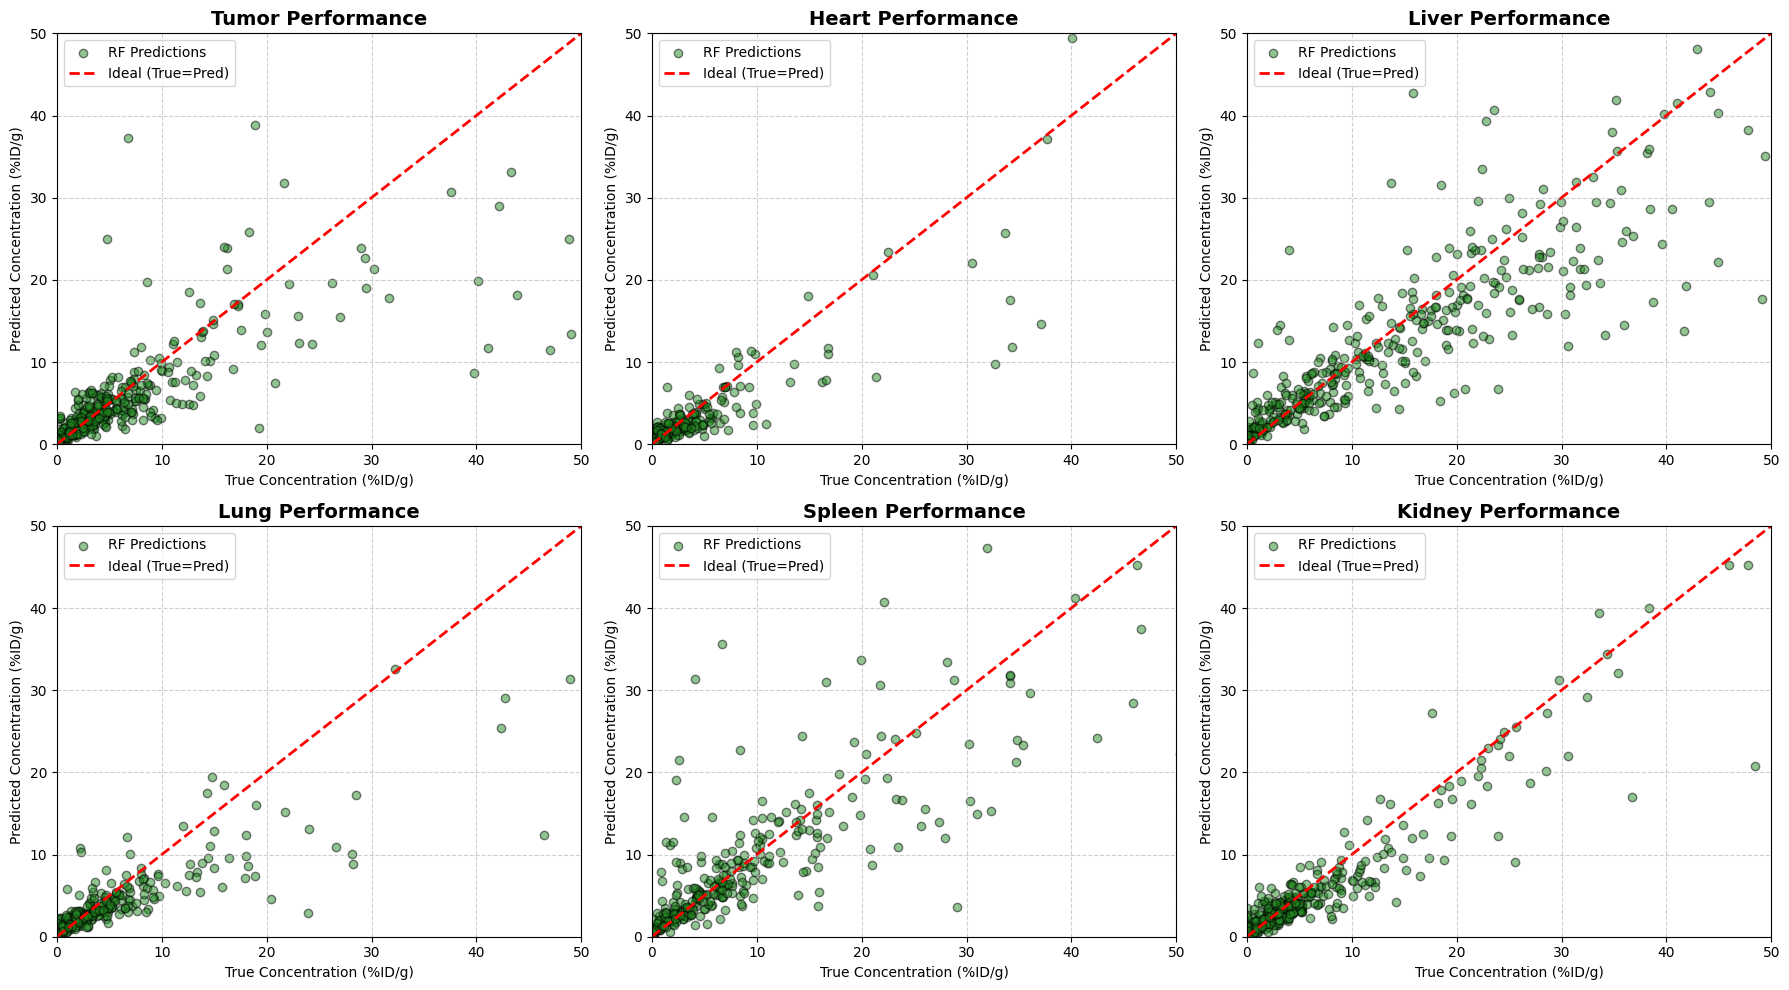

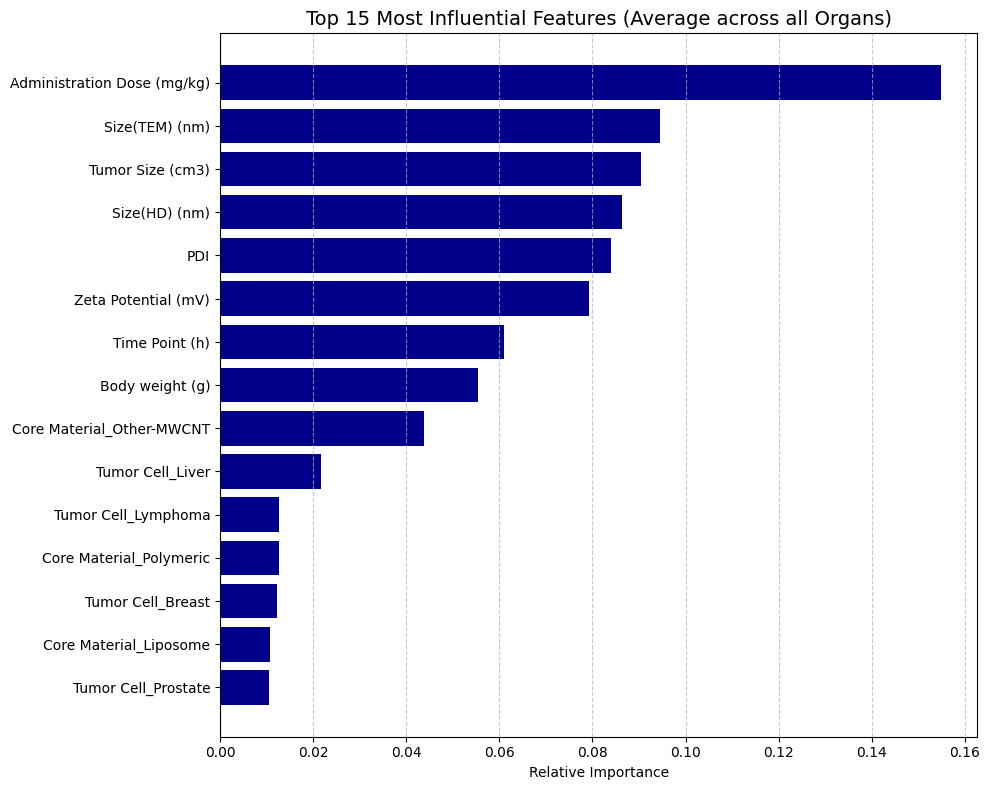

In [ ]:
import matplotlib.pyplot as plt

def plot_rf_results(true_raw, pred_raw, mask, organ_cols, importance_data=None, feature_names=None):
    # 1. SCATTER PLOTS (Predicted vs True)
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()
    axis_limit = 50

    for i, organ in enumerate(organ_cols):
        ax = axes[i]
        organ_mask = mask[:, i]

        # Filter data for the specific organ
        y_true = true_raw[organ_mask, i]
        y_pred = pred_raw[organ_mask, i]

        ax.scatter(y_true, y_pred, alpha=0.5, color='forestgreen', edgecolor='k', label='RF Predictions')
        ax.plot([0, axis_limit], [0, axis_limit], 'r--', lw=2, label='Ideal (True=Pred)')

        clean_title = organ.replace(" Concentration (%ID/g)", "")
        ax.set_title(f'{clean_title} Performance', fontsize=14, fontweight='bold')
        ax.set_xlabel('True Concentration (%ID/g)')
        ax.set_ylabel('Predicted Concentration (%ID/g)')
        ax.set_xlim(0, axis_limit)
        ax.set_ylim(0, axis_limit)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.show()

    # 2. FEATURE IMPORTANCE PLOT
    if importance_data and feature_names is not None:
        # Average importance across all 6 organ models
        avg_importance = np.mean([model.feature_importances_ for model in importance_data.values()], axis=0)

        # Get top 15 features
        indices = np.argsort(avg_importance)[-15:]

        plt.figure(figsize=(10, 8))
        plt.title("Top 15 Most Influential Features (Average across all Organs)", fontsize=14)
        plt.barh(range(len(indices)), avg_importance[indices], color='darkblue', align='center')
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel('Relative Importance')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(numeric_cols) + list(cat_feature_names)

# Execute the plotting
plot_rf_results(
    y_test_raw,
    y_pred_raw,
    mask,
    target_cols,
    importance_data=rf_predictor.models,
    feature_names=all_feature_names
)